## Digital Finance, Forecasting & Analytics Platform
## Module 4.4: FP&A Visualization & Analytical Layer (Python + SQLAlchemy + Pandas)

This module represents the analytical and visualization layer of the FP&A cycle. Its objective is to extract IFRS views and fact tables directly from the Financial Data Warehouse (PostgreSQL) and transform them into analytical datasets for performance analysis, scenario comparison, and executive visualizations (Actual vs Forecast, trends and KPIs).

**Note:** This module exclusively analyzes IFRS views and fact tables related to **ScenarioKey = 3 (Forecast)**, ensuring that all analytical outputs, trends and visualizations are fully aligned with the forecasted financial scenario.

It consolidates IFRS SQL views and fact tables, prepares analytical time series, and generates visual representations that support financial decision-making and management reporting.

### Setup & Imports

In [1]:
from sqlalchemy import create_engine, text
from sqlalchemy.exc import SQLAlchemyError
from dotenv import load_dotenv
import os
import logging
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#print(os.getcwd())

In [3]:
### Logging configuration:
# This configuration initializes a centralized logging system for the IFRS automation pipeline.
# It automatically records all important execution events (e.g., connection status, data extraction,
# transformations, warnings, and errors) into a persistent log file named 'ifrs_pipeline.log'.
# These logs enable traceability, auditing, and performance monitoring across all modules.

import logging

# Remove any existing log handlers (Jupyter sets one by default)
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

# Now configure your own file-based logging
logging.basicConfig(
    filename='ifrs_pipeline.log',
    filemode='w',  # or "a" for append
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

logging.info("✅ Logging system initialized successfully.")

# Force immediate file creation
for handler in logging.root.handlers:
    handler.flush()


### 1- Database Connection

### 1. Database Connection

Establishes a secure connection to the PostgreSQL Data Warehouse (finance_ifrs_dw) using SQLAlchemy. This schema contains the IFRS financial data prepared in Module 2,
including fact tables, dimension tables, and analytical views.

The connection enables automated extraction of:
- **IFRS views:** vw_pl_annual_pivot, vw_bs_annual_pivot, vw_cf_annual_pivot  
- **Fact tables:** sales, cogs, opex, equity, assets, taxes, etc.

Connection validation is performed using a `try/except` block to ensure error handling and prevent pipeline interruption. The schema `finance_ifrs_dw` was validated in
DBeaver to ensure integrity prior to extraction.


In [4]:
### Database connection (with error handling)

load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

try:
    with engine.connect() as connection:
        connection.execute(text("SET search_path TO finance_ifrs_dw;"))
        print("✅ Database connection + search_path OK")
except SQLAlchemyError as e:
    print("❌ Error:", e)


✅ Database connection + search_path OK


### 2- Data Extraction

**2. Data Extraction**

This section performs the automated extraction of IFRS data from the PostgreSQL Data Warehouse (finance_ifrs_dw) using SQLAlchemy and Pandas.

The process is divided into two stages:

**2.1 Extraction from 3 IFRS Statement Views**
Imports the three core IFRS views directly from the data warehouse:
- vw_pl_annual_pivot → Income Statement (Profit & Loss)  
- vw_bs_annual_pivot → Balance Sheet  
- vw_cf_annual_pivot → Cash Flow Statement  

Each view is read into a Pandas DataFrame for further transformation, calculation, and validation.

**2.2 Extraction of All 10 Fact Tables**
Applies a generic SQL function (extract_fact_table()) to dynamically extract the ten fact tables that support analytical and IFRS KPIs: fact_sales, fact_cogs, fact_opex, fact_depreciation, fact_assets, fact_debt, fact_equity, fact_taxes, fact_workingcapital, fact_cashflow.

The extraction joins each fact with the dim_date table to ensure temporal consistency, and stores all results in Pandas DataFrames rounded to two decimals.

This step ensures data completeness and prepares the analytical layer for IFRS indicator calculation and visualization in subsequent modules.

This extraction layer operationalizes the Star Schema defined in Module 2 (finance_ifrs_dw), ensuring referential integrity across dimensions and facts (dim_date, dim_account, etc.) for subsequent IFRS indicator calculations.

2.1- Extraction from 3 Statement Views

In [5]:
### Function to extract 3 statement views

# Dictionary of views
views = {
    "P&L": "finance_ifrs_dw.vw_pl_annual_pivot_forecast",
    "P&L_m": "finance_ifrs_dw.vw_pl_monthly_forecast",
    "Balance_Sheet": "finance_ifrs_dw.vw_bs_annual_pivot_forecast",
    "Cash_Flow": "finance_ifrs_dw.vw_cf_annual_pivot_forecast"
}

# Read all views into separate DataFrames
dfs = {}
for name, view in views.items():
    query = f"SELECT * FROM {view};"  # sem ORDER BY
    dfs[name] = pd.read_sql(query, engine)

# Access each DataFrame
df_pl = dfs["P&L"].round(2)
df_plm = dfs["P&L_m"].round(2)
df_bs = dfs["Balance_Sheet"].round(2)
df_cf = dfs["Cash_Flow"].round(2)

2.2- Extraction of all 10 Facts

In [6]:
schema = "finance_ifrs_dw"

# Função genérica para extrair cada fact table
def extract_fact_table(fact_name: str) -> pd.DataFrame:
    query = f"""
        SELECT 
            d.MonthYear,
            f.*
        FROM {schema}.{fact_name} f
        JOIN {schema}.dim_date d 
            ON f.DateKey = d.DateKey
        ORDER BY d.MonthYear;
    """
    return pd.read_sql(query, engine)

fact_tables = [
    "fact_sales",
    "fact_cogs",
    "fact_opex",
    "fact_depreciation",
    "fact_assets",
    "fact_debt",
    "fact_equity",
    "fact_taxes",
    "fact_workingcapital",
    "fact_price_volume",
    "fact_cashflow"
]

facts = {}

for fact in fact_tables:
    facts[fact] = extract_fact_table(fact).round(2)


### 3- Data Transformation, Calculations & Report Generation

**3.1 Data Quality Function**

Defines a reusable function `check_data_quality()` to perform essential metadata and data quality checks on each extracted dataset. The function validates structure, completeness, and consistency by reporting:

- Dataset dimensions (rows × columns)  
- Missing values per column  
- Duplicate records  
- Data type overview  

All results are printed in the notebook and logged to the pipeline log file (`ifrs_pipeline.log`) for traceability and audit purposes.


In [7]:
def check_data_quality(df: pd.DataFrame, name: str) -> None:
    """
    Performs basic metadata and data quality checks on a given DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame to check.
    name : str
        Logical name of the dataset (e.g., 'P&L', 'Balance Sheet', 'fact_sales').

    Returns
    -------
    None
        Prints and logs metadata and data quality results.
    """
    try:
        logging.info(f"🔍 Checking dataframe: {name}")
        print(f"\n🔍 Checking dataframe: {name}")
        print(f"Shape: {df.shape}")
        print("Missing values:\n", df.isna().sum())
        print("Duplicates:", df.duplicated().sum())
        print("Dtypes:\n", df.dtypes)
        print("-" * 50)
    except Exception as e:
        logging.error(f"❌ Data quality check failed for {name}: {str(e)}")
        print(f"❌ Error while checking {name}: {str(e)}")


3.2- From 3 Statement Views

In [8]:
### P&L - Profit and loss Statement - Annually
# --- Metadata & data quality checks ---
check_data_quality(df_pl, "Profit & Loss")
df_pl


🔍 Checking dataframe: Profit & Loss
Shape: (10, 5)
Missing values:
 accountkey        0
account           0
ifrs_reference    0
2023              0
2024              0
dtype: int64
Duplicates: 0
Dtypes:
 accountkey          int64
account            object
ifrs_reference     object
2023              float64
2024              float64
dtype: object
--------------------------------------------------


,accountkey,account,ifrs_reference,2023,2024
0,101,Revenue,IFRS 15,30027.34,32024.57
1,102,CostOfGoodsSold,IAS 2,15220.84,16590.87
2,103,GrossProfit,IAS 1,14806.50,15433.70
3,104,OperatingExpenses,IAS 1,7807.13,7045.42
4,105,EBITDA,IAS 1,6999.37,8388.28
5,106,DepreciationExpense,IAS 16,1589.27,1741.54
6,107,FinancialResults,IFRS 9,-343.01,-337.54
7,111,EBT,IAS 1,5067.09,6309.20
8,113,TotalTaxes,IAS 12,1520.12,1892.77
9,114,NetIncome,IAS 1,3546.97,4416.43


In [9]:
### P&L - Margins Calculations
# Transformation, Calculations & Report Generation

pl = df_pl.copy()
pl = pl.drop(columns=['accountkey', 'ifrs_reference']) 
pl = pl.set_index('account') 
pl.loc['Gross_%'] = round(pl.loc['GrossProfit'] / pl.loc['Revenue'],4)*100
pl.loc['EBITDA_%'] = round(pl.loc['EBITDA'] / pl.loc['Revenue'],4)*100
pl.loc['EBT_%'] = round(pl.loc['EBT'] / pl.loc['Revenue'],4)*100
pl.loc['Net_%'] = round(pl.loc['NetIncome'] / pl.loc['Revenue'],4)*100

order = [
    'Revenue',
    'CostOfGoodsSold',
    'GrossProfit',
    'Gross_%',
    'OperatingExpenses',
    'EBITDA',
    'EBITDA_%',
    'DepreciationExpense',
    'FinancialResults',
    'EBT',
    'EBT_%',
    'TotalTaxes',
    'NetIncome',
    'Net_%'
]

pl = pl.loc[order]
pl.to_csv("py_files_cvs/p&l_annual.csv")
pl

,2023,2024
account,,
Revenue,30027.34,32024.57
CostOfGoodsSold,15220.84,16590.87
GrossProfit,14806.50,15433.70
Gross_%,49.31,48.19
OperatingExpenses,7807.13,7045.42
EBITDA,6999.37,8388.28
EBITDA_%,23.31,26.19
DepreciationExpense,1589.27,1741.54
FinancialResults,-343.01,-337.54


In [10]:
### P&L - Profit and loss Statement - Montlhy
# --- Metadata & data quality checks ---
check_data_quality(df_plm, "Profit & Loss")
df_plm.head()


🔍 Checking dataframe: Profit & Loss
Shape: (24, 16)
Missing values:
 datekey              0
year                 0
month                0
revenue              0
cogs                 0
COGS (%)             0
gross_profit         0
Gross (%)            0
opex                 0
Opex (%)             0
ebitda               0
depreciation         0
financial_results    0
ebt                  0
totaltaxes           0
net_income           0
dtype: int64
Duplicates: 0
Dtypes:
 datekey                int64
year                   int64
month                  int64
revenue              float64
cogs                 float64
COGS (%)             float64
gross_profit         float64
Gross (%)            float64
opex                 float64
Opex (%)             float64
ebitda               float64
depreciation         float64
financial_results    float64
ebt                  float64
totaltaxes           float64
net_income           float64
dtype: object
------------------------------------------------

,datekey,year,month,revenue,cogs,COGS (%),gross_profit,Gross (%),opex,Opex (%),ebitda,depreciation,financial_results,ebt,totaltaxes,net_income
0,202301,2023,1,1863.86,944.79,50.69,919.07,49.31,484.59,26.0,434.48,132.44,-28.58,273.46,126.68,146.78
1,202302,2023,2,2133.73,1081.60,50.69,1052.13,49.31,554.77,26.0,497.36,132.44,-28.58,336.34,126.68,209.66
2,202303,2023,3,2494.09,1264.25,50.69,1229.84,49.31,648.46,26.0,581.38,132.44,-28.58,420.36,126.68,293.68
3,202304,2023,4,2452.89,1243.38,50.69,1209.51,49.31,637.76,26.0,571.75,132.44,-28.58,410.73,126.68,284.05
4,202305,2023,5,2397.58,1215.32,50.69,1182.26,49.31,623.37,26.0,558.89,132.44,-28.58,397.87,126.68,271.19


In [11]:
### P&L Monthly
# Transformation, Calculations & Report Generation

plm = df_plm.copy()
plm = plm.drop(columns=[
    'year',
    'month',
    'COGS (%)',
    'Gross (%)',
    'Opex (%)',
])
plm.to_csv("py_files_cvs/p&l_monthly.csv")
plm.head()

,datekey,revenue,cogs,gross_profit,opex,ebitda,depreciation,financial_results,ebt,totaltaxes,net_income
0,202301,1863.86,944.79,919.07,484.59,434.48,132.44,-28.58,273.46,126.68,146.78
1,202302,2133.73,1081.60,1052.13,554.77,497.36,132.44,-28.58,336.34,126.68,209.66
2,202303,2494.09,1264.25,1229.84,648.46,581.38,132.44,-28.58,420.36,126.68,293.68
3,202304,2452.89,1243.38,1209.51,637.76,571.75,132.44,-28.58,410.73,126.68,284.05
4,202305,2397.58,1215.32,1182.26,623.37,558.89,132.44,-28.58,397.87,126.68,271.19


In [12]:
### Balance Sheet Statement
# --- Metadata & data quality checks ---
check_data_quality(df_bs, "Balance Sheet")
df_bs


🔍 Checking dataframe: Balance Sheet
Shape: (19, 5)
Missing values:
 accountkey        0
account           0
ifrs_reference    0
2023              0
2024              0
dtype: int64
Duplicates: 0
Dtypes:
 accountkey          int64
account            object
ifrs_reference     object
2023              float64
2024              float64
dtype: object
--------------------------------------------------


,accountkey,account,ifrs_reference,2023,2024
0,201,Cash,IAS 1,842.48,1110.78
1,202,AccountsReceivable,IAS 1,6985.12,7067.20
2,203,Inventory,IAS 2,3653.00,3815.90
3,204,CurrentAssets,IAS 1,11480.60,11993.88
4,205,PPE,IAS 16,21769.22,23714.92
5,206,IntangibleAssets,IAS 38,3712.67,3949.82
6,207,DeferredTaxes,IAS 12,0.00,0.00
7,208,OtherNonCurrentAssets,IAS 1,3620.97,3451.16
8,209,NonCurrentAssets,IAS 1,29102.86,31115.90
9,210,TotalAssets,IAS 1,40583.46,43109.78


In [13]:
### Balance Sheet Statement
# Transformation, Calculations & Report Generation

bs = df_bs.copy()
bs = bs.drop(columns=['accountkey', 'ifrs_reference']) 
bs = bs.set_index('account') 
bs.loc['BalanceCheck'] = round(bs.loc['TotalAssets'] - bs.loc['TotalLiabilities'] - bs.loc['TotalEquity'],2)*100
bs.to_csv("py_files_cvs/balance_annual.csv")
bs

,2023,2024
account,,
Cash,842.48,1110.78
AccountsReceivable,6985.12,7067.20
Inventory,3653.00,3815.90
CurrentAssets,11480.60,11993.88
PPE,21769.22,23714.92
IntangibleAssets,3712.67,3949.82
DeferredTaxes,0.00,0.00
OtherNonCurrentAssets,3620.97,3451.16
NonCurrentAssets,29102.86,31115.90


In [14]:
### Balance Sheet Statement
# Balance Sheet Reconciliation Test
try:
    assert abs(bs.loc['TotalAssets'].sum() - (bs.loc['TotalLiabilities'].sum() + bs.loc['TotalEquity'].sum())) < 0.0000001
    print("✅ Balance Sheet balanced successfully.")
except AssertionError:
    print("❌ Balance Sheet not balanced!")


✅ Balance Sheet balanced successfully.


In [15]:
### Cash Flow Statement
# --- Metadata & data quality checks ---
check_data_quality(df_cf, "Cash Flow")
df_cf


🔍 Checking dataframe: Cash Flow
Shape: (8, 5)
Missing values:
 accountkey        0
account           0
ifrs_reference    0
2023              0
2024              0
dtype: int64
Duplicates: 0
Dtypes:
 accountkey          int64
account            object
ifrs_reference     object
2023              float64
2024              float64
dtype: object
--------------------------------------------------


,accountkey,account,ifrs_reference,2023,2024
0,301,DeltaAR,IAS 7,-139.11,-82.08
1,302,DeltaInventory,IAS 7,-84.09,-154.62
2,303,DeltaAP,IAS 7,-33.08,215.13
3,304,DeltaDebt,IAS 7,-36.90,-51.90
4,305,CFO,IAS 7,4879.96,6136.40
5,306,CFI,IAS 7,-3492.56,-3687.23
6,307,CFF,IAS 7,-1987.73,-2480.94
7,308,CashEnd,IAS 7,842.48,1110.78


In [16]:
### Cash Flow Statement
# Transformation, Calculations & Report Generation

cf = df_cf.copy()
cf = cf.drop(columns=['accountkey', 'ifrs_reference']) 
cf = cf.set_index('account') 
cf.to_csv("py_files_cvs/cashfow_annual.csv")
cf

,2023,2024
account,,
DeltaAR,-139.11,-82.08
DeltaInventory,-84.09,-154.62
DeltaAP,-33.08,215.13
DeltaDebt,-36.90,-51.90
CFO,4879.96,6136.40
CFI,-3492.56,-3687.23
CFF,-1987.73,-2480.94
CashEnd,842.48,1110.78


3.3- From all Facts Tebles

In [17]:
### Fact depreciation
depreciation = facts["fact_depreciation"].copy()
depreciation = depreciation[depreciation["scenariokey"] == 3]

# --- Metadata & data quality checks ---
check_data_quality(facts["fact_depreciation"], "Fact Depreciation")

depreciation.drop(columns = ["monthyear", "accountkey", "accountname"], inplace = True)
depreciation.rename(columns={'amount': 'DepreciationExpense'}, inplace=True)

# Report Generation - Fact depreciation Monthly
depreciation.to_csv("py_files_cvs/depreciation.csv", index= False)

depreciation.head()


🔍 Checking dataframe: Fact Depreciation
Shape: (204, 6)
Missing values:
 monthyear      0
datekey        0
accountkey     0
accountname    0
amount         0
scenariokey    0
dtype: int64
Duplicates: 0
Dtypes:
 monthyear       object
datekey          int64
accountkey       int64
accountname     object
amount         float64
scenariokey      int64
dtype: object
--------------------------------------------------


,datekey,DepreciationExpense,scenariokey
157,202301,132.44,3
159,202302,132.44,3
160,202303,132.44,3
163,202304,132.44,3
165,202305,132.44,3


In [18]:
### Fact assets
assets = facts["fact_assets"].copy()
assets = assets[assets["scenariokey"] == 3]

# --- Metadata & data quality checks ---
check_data_quality(facts["fact_assets"], "Fact Assets")

assets.drop(columns = "monthyear", inplace = True)
assets = assets.pivot(index="datekey", columns="accountname", values="amount")

# Report Generation - Fact assets Monthly
assets.to_csv("py_files_cvs/assets.csv")

assets.head()


🔍 Checking dataframe: Fact Assets
Shape: (1224, 6)
Missing values:
 monthyear      0
datekey        0
accountkey     0
accountname    0
amount         0
scenariokey    0
dtype: int64
Duplicates: 0
Dtypes:
 monthyear       object
datekey          int64
accountkey       int64
accountname     object
amount         float64
scenariokey      int64
dtype: object
--------------------------------------------------


accountname,Capex,DeferredTaxes,IntangibleAssets,OtherNonCurrentAssets,PPE,TaxBasis
datekey,,,,,,
202301,291.05,0.0,309.39,301.75,1814.1,1632.69
202302,291.05,0.0,309.39,301.75,1814.1,1632.69
202303,291.05,0.0,309.39,301.75,1814.1,1632.69
202304,291.05,0.0,309.39,301.75,1814.1,1632.69
202305,291.05,0.0,309.39,301.75,1814.1,1632.69


In [19]:
### Fact debt
debt = facts["fact_debt"].copy()
debt = debt[debt["scenariokey"] == 3]


# --- Metadata & data quality checks ---
check_data_quality(facts["fact_debt"], "Fact Debt")

debt.drop(columns = "monthyear", inplace = True)
debt = debt.pivot(index="datekey", columns="accountname", values="amount")


# Report Generation - Fact debt Monthly
debt.to_csv("py_files_cvs/debt.csv")

debt.head()


🔍 Checking dataframe: Fact Debt
Shape: (816, 6)
Missing values:
 monthyear      0
datekey        0
accountkey     0
accountname    0
amount         0
scenariokey    0
dtype: int64
Duplicates: 0
Dtypes:
 monthyear       object
datekey          int64
accountkey       int64
accountname     object
amount         float64
scenariokey      int64
dtype: object
--------------------------------------------------


accountname,InterestIncome,LTInterestExpense,NonCurrentLiabilities,STInterestExpense
datekey,,,,
202301,0.75,29.33,733.24,0.0
202302,0.75,29.33,733.24,0.0
202303,0.75,29.33,733.24,0.0
202304,0.75,29.33,733.24,0.0
202305,0.75,29.33,733.24,0.0


In [20]:
### Fact equity
equity = facts["fact_equity"].copy()
equity = equity[equity["scenariokey"] == 3]

# --- Metadata & data quality checks ---
check_data_quality(facts["fact_equity"], "Fact Equity")

equity.drop(columns = "monthyear", inplace = True)
equity = equity.pivot(index="datekey", columns="accountname", values="amount")


# Report Generation - Fact equity Monthly
equity.to_csv("py_files_cvs/equity.csv")

equity.head()


🔍 Checking dataframe: Fact Equity
Shape: (612, 6)
Missing values:
 monthyear      0
datekey        0
accountkey     0
accountname    0
amount         0
scenariokey    0
dtype: int64
Duplicates: 0
Dtypes:
 monthyear       object
datekey          int64
accountkey       int64
accountname     object
amount         float64
scenariokey      int64
dtype: object
--------------------------------------------------


accountname,Capital,Dividends,RetainedEarnings
datekey,,,
202301,833.33,162.57,1396.81
202302,833.33,162.57,1396.81
202303,833.33,162.57,1396.81
202304,833.33,162.57,1396.81
202305,833.33,162.57,1396.81


In [21]:
### Fact taxes
taxes = facts["fact_taxes"].copy()
taxes = taxes[taxes["scenariokey"] == 3]

# --- Metadata & data quality checks ---
check_data_quality(facts["fact_taxes"], "Fact Taxes")

taxes.drop(columns = "monthyear", inplace = True)
taxes = taxes.pivot(index="datekey", columns="accountname", values="amount")


# Report Generation - Fact taxes Monthly
taxes.to_csv("py_files_cvs/taxes.csv")

taxes.head()


🔍 Checking dataframe: Fact Taxes
Shape: (408, 6)
Missing values:
 monthyear      0
datekey        0
accountkey     0
accountname    0
amount         0
scenariokey    0
dtype: int64
Duplicates: 0
Dtypes:
 monthyear       object
datekey          int64
accountkey       int64
accountname     object
amount         float64
scenariokey      int64
dtype: object
--------------------------------------------------


accountname,CurrentTaxExpense,TotalTaxes
datekey,,
202301,126.68,126.68
202302,126.68,126.68
202303,126.68,126.68
202304,126.68,126.68
202305,126.68,126.68


In [22]:
### Fact cashflow
cashflow = facts["fact_cashflow"].copy()
cashflow = cashflow[cashflow["scenariokey"] == 3]

# --- Metadata & data quality checks ---
check_data_quality(facts["fact_cashflow"], "Fact Cash Flow")

cashflow.drop(columns = "monthyear", inplace = True)
cashflow = cashflow.pivot(index="datekey", columns="accountname", values="amount")


# Report Generation - Fact cashflow Monthly
cashflow.to_csv("py_files_cvs/cashflow.csv")

cashflow.head()


🔍 Checking dataframe: Fact Cash Flow
Shape: (1836, 6)
Missing values:
 monthyear      0
datekey        0
accountkey     0
accountname    0
amount         0
scenariokey    0
dtype: int64
Duplicates: 0
Dtypes:
 monthyear       object
datekey          int64
accountkey       int64
accountname     object
amount         float64
scenariokey      int64
dtype: object
--------------------------------------------------


accountname,CFF,CFI,CFO,CashEnd,DeltaAP,DeltaAR,DeltaDebt,DeltaInventory,RevolvingCredit
datekey,,,,,,,,,
202301,-165.64,-291.05,406.66,70.21,-2.76,-11.59,-3.08,-7.01,0.0
202302,-165.64,-291.05,406.66,70.21,-2.76,-11.59,-3.08,-7.01,0.0
202303,-165.64,-291.05,406.66,70.21,-2.76,-11.59,-3.08,-7.01,0.0
202304,-165.64,-291.05,406.66,70.21,-2.76,-11.59,-3.08,-7.01,0.0
202305,-165.64,-291.05,406.66,70.21,-2.76,-11.59,-3.08,-7.01,0.0


In [23]:
### Fact workingcapital
workingcapital = facts["fact_workingcapital"].copy()
workingcapital = workingcapital[workingcapital["scenariokey"] == 3]

# --- Metadata & data quality checks ---
check_data_quality(facts["fact_workingcapital"], "Fact Working Capital")

workingcapital.drop(columns = "monthyear", inplace = True)
workingcapital = workingcapital.pivot(index="datekey", columns="accountname", values="amount")


# Report Generation - Fact cashflow Monthly
workingcapital.to_csv("py_files_cvs/workingcapital.csv")

workingcapital.head()


🔍 Checking dataframe: Fact Working Capital
Shape: (612, 6)
Missing values:
 monthyear      0
datekey        0
accountkey     0
accountname    0
amount         0
scenariokey    0
dtype: int64
Duplicates: 0
Dtypes:
 monthyear       object
datekey          int64
accountkey       int64
accountname     object
amount         float64
scenariokey      int64
dtype: object
--------------------------------------------------


accountname,AccountsPayable,AccountsReceivable,Inventory
datekey,,,
202301,418.57,582.09,304.42
202302,418.57,582.09,304.42
202303,418.57,582.09,304.42
202304,418.57,582.09,304.42
202305,418.57,582.09,304.42


In [24]:
### Fact cogs
cogs = facts["fact_cogs"].copy()
cogs = cogs[cogs["scenariokey"] == 3]

# --- Metadata & data quality checks ---
check_data_quality(facts["fact_cogs"], "Fact COGS")

product_names = {1: "Ind", 2: "Aut", 3: "Elec"}
cogs["product"] = cogs["productkey"].map(product_names)

cogs.drop(columns = ["monthyear", "productkey"], inplace = True)
cogs = (
    cogs.pivot_table(
        index="datekey",
        columns="product",
        values="amount",
        aggfunc="sum"
    )
    .reset_index()
)
#cogs = cogs.set_index("datekey")

# Report Generation - Fact cogs Monthly
cogs.to_csv("py_files_cvs/cogs.csv")

cogs.head()


🔍 Checking dataframe: Fact COGS
Shape: (612, 7)
Missing values:
 monthyear      0
datekey        0
accountkey     0
accountname    0
productkey     0
amount         0
scenariokey    0
dtype: int64
Duplicates: 0
Dtypes:
 monthyear       object
datekey          int64
accountkey       int64
accountname     object
productkey       int64
amount         float64
scenariokey      int64
dtype: object
--------------------------------------------------


product,datekey,Aut,Elec,Ind
0,202301,333.29,241.76,369.74
1,202302,381.55,276.77,423.28
2,202303,445.98,323.51,494.76
3,202304,438.62,318.17,486.59
4,202305,428.72,310.99,475.61


In [25]:
 ### Fact opex
opex = facts["fact_opex"].copy()
opex = opex[opex["scenariokey"] == 3]

# --- Metadata & data quality checks ---
check_data_quality(facts["fact_opex"], "Fact Opex")

businessunit_names = {1: "Production", 2: "R&D", 3: "Sales", 4: "Marketing", 5: "Logistics", 6: "Administration",  7: "FixedCosts"}

opex["businessunit"] = opex["businessunitkey"].map(businessunit_names)

opex.drop(columns = ["monthyear", "businessunitkey"], inplace = True)
opex = (
    opex.pivot_table(
        index="datekey",
        columns="businessunit",
        values="amount",
        aggfunc="sum"
    )
    .reset_index()
)
#opex = opex.set_index("datekey")

# Report Generation - Fact opex Monthly
opex.to_csv("py_files_cvs/opex.csv")

opex.head()


🔍 Checking dataframe: Fact Opex
Shape: (1428, 7)
Missing values:
 monthyear          0
datekey            0
accountkey         0
accountname        0
businessunitkey    0
amount             0
scenariokey        0
dtype: int64
Duplicates: 0
Dtypes:
 monthyear           object
datekey              int64
accountkey           int64
accountname         object
businessunitkey      int64
amount             float64
scenariokey          int64
dtype: object
--------------------------------------------------


businessunit,datekey,Administration,FixedCosts,Logistics,Marketing,Production,R&D,Sales
0,202301,53.19,73.78,69.10,81.07,132.68,45.94,28.83
1,202302,60.89,84.46,79.11,92.81,151.90,52.59,33.01
2,202303,71.17,98.73,92.47,108.49,177.55,61.47,38.58
3,202304,69.99,97.10,90.94,106.70,174.62,60.46,37.95
4,202305,68.41,94.91,88.89,104.29,170.68,59.10,37.09


In [26]:
### Fact Sales – Data Preview
sales = facts["fact_sales"].copy()
sales = sales[sales["scenariokey"] == 3]

# --- Metadata & data quality checks ---
check_data_quality(facts["fact_sales"], "Fact Sales")

sales.tail()


🔍 Checking dataframe: Fact Sales
Shape: (1836, 8)
Missing values:
 monthyear      0
datekey        0
accountkey     0
accountname    0
channelkey     0
productkey     0
amount         0
scenariokey    0
dtype: int64
Duplicates: 0
Dtypes:
 monthyear       object
datekey          int64
accountkey       int64
accountname     object
channelkey       int64
productkey       int64
amount         float64
scenariokey      int64
dtype: object
--------------------------------------------------


,monthyear,datekey,accountkey,accountname,channelkey,productkey,amount,scenariokey
1822,2024-12,202412,101,Revenue,2,2,371.52,3
1823,2024-12,202412,101,Revenue,2,1,178.44,3
1824,2024-12,202412,101,Revenue,1,3,50.41,3
1825,2024-12,202412,101,Revenue,1,2,567.69,3
1826,2024-12,202412,101,Revenue,1,1,834.55,3


In [27]:
### Fact Sales – Channel and Product Mapping
sales = facts["fact_sales"].copy()
sales = sales[sales["scenariokey"] == 3]
channel_names = {1: "Direct", 2: "Retail", 3: "Online"}
product_names = {1: "Ind", 2: "Aut", 3: "Elec"}

sales["channel"] = sales["channelkey"].map(channel_names)
sales["product"] = sales["productkey"].map(product_names)

sales = sales.drop(columns=["monthyear", "channelkey", "productkey", "accountkey", "accountname"])
#sales = sales.set_index("datekey")
sales.tail()

,datekey,amount,scenariokey,channel,product
1822,202412,371.52,3,Retail,Aut
1823,202412,178.44,3,Retail,Ind
1824,202412,50.41,3,Direct,Elec
1825,202412,567.69,3,Direct,Aut
1826,202412,834.55,3,Direct,Ind


In [28]:
### Fact Sales – Aggregation and Pivot
tbl = (
    sales
    .groupby(["datekey", "channel", "product"])["amount"]
    .sum()
    .unstack(["channel", "product"])  
)

tot_prod = tbl.T.groupby(level="product").sum().T
tot_chan = tbl.T.groupby(level="channel").sum().T
sales_all = pd.concat([tbl, tot_prod, tot_chan], axis=1)
sales_all["Revenue"] = sales_all[["Direct", "Retail", "Online"]].sum(axis=1)

sales_all.columns = [
    "_".join([str(c) for c in col if c]).strip()
    if isinstance(col, tuple) else col
    for col in sales_all.columns
]

sales_all.loc["Revenue"] = sales_all.sum()

# Report Generation - Fact sales Monthly
sales_all.to_csv("py_files_cvs/sales_all.csv")

sales_all.head()

,Direct_Aut,Direct_Elec,Direct_Ind,Online_Aut,Online_Elec,Online_Ind,Retail_Aut,Retail_Elec,Retail_Ind,Aut,Elec,Ind,Direct,Online,Retail,Revenue
datekey,,,,,,,,,,,,,,,,
202301,329.35,29.10,484.95,132.69,236.07,82.10,217.02,248.34,104.24,679.06,513.51,671.29,843.40,450.86,569.60,1863.86
202302,377.03,33.31,555.17,151.90,270.26,93.99,248.44,284.30,119.33,777.37,587.87,768.49,965.51,516.15,652.07,2133.73
202303,440.71,38.94,648.93,177.56,315.90,109.86,290.39,332.32,139.48,908.66,687.16,898.27,1128.58,603.32,762.19,2494.09
202304,433.43,38.29,638.21,174.62,310.68,108.05,285.60,326.83,137.18,893.65,675.80,883.44,1109.93,593.35,749.61,2452.89
202305,423.66,37.43,623.82,170.69,303.67,105.61,279.16,319.46,134.08,873.51,660.56,863.51,1084.91,579.97,732.70,2397.58


In [29]:
### Others Fact Sales Aggregations 
sales_base = (
    sales
    .reset_index()  
    .groupby(["datekey", "channel", "product"], as_index=False)
    .agg(amount_sum=("amount", "sum"))
)

sales_by_channel = (
    sales_base
    .groupby(["datekey", "channel"], as_index=False)["amount_sum"]
    .sum()
    .pivot(index="datekey", columns="channel", values="amount_sum")
    .rename_axis(None, axis=1)
).reset_index()

sales_by_product = (
    sales_base
    .groupby(["datekey", "product"], as_index=False)["amount_sum"]
    .sum()
    .pivot(index="datekey", columns="product", values="amount_sum")
    .rename_axis(None, axis=1)
).reset_index()

sales_matrix = sales.pivot_table(
    index="product", columns="channel", values="amount", aggfunc="sum"
).reset_index()

sales_base.head()


,datekey,channel,product,amount_sum
0,202301,Direct,Aut,329.35
1,202301,Direct,Elec,29.10
2,202301,Direct,Ind,484.95
3,202301,Online,Aut,132.69
4,202301,Online,Elec,236.07


In [30]:
### Sales by Channel over Time
sbc = sales_by_channel.copy()
sbc["datekey"] = pd.to_datetime(sbc["datekey"], format="%Y%m")
sbc["datekey"] = sbc["datekey"].dt.strftime("%Y")
sbcy = sbc.groupby("datekey")[["Direct", "Online", "Retail"]].sum()
sbcy["Revenue"] = sbcy["Direct"] + sbcy["Online"] + sbcy["Retail"]
sbcy["Direct_%"] = (sbcy["Direct"] / sbcy["Revenue"]*100).round(2)
sbcy["Online_%"] = (sbcy["Online"] / sbcy["Revenue"]*100).round(2)
sbcy["Retail_%"] = (sbcy["Retail"] / sbcy["Revenue"]*100).round(2)
order = ['Revenue', 'Direct', 'Direct_%', 'Online', 'Online_%', 'Retail', 'Retail_%']
sbcy[order]

,Revenue,Direct,Direct_%,Online,Online_%,Retail,Retail_%
datekey,,,,,,,
2023,30027.34,13587.38,45.25,7263.62,24.19,9176.34,30.56
2024,32024.57,14487.93,45.24,7801.19,24.36,9735.45,30.40


In [31]:
### Sales by Product over Time
sbp = sales_by_product.copy()
sbp["datekey"] = pd.to_datetime(sbp["datekey"], format="%Y%m")
sbp["datekey"] = sbp["datekey"].dt.strftime("%Y")
sbpy = sbp.groupby("datekey")[["Aut", "Elec", "Ind"]].sum()
sbpy["Revenue"] = sbpy["Aut"] + sbpy["Elec"] + sbpy["Ind"]
sbpy["Aut_%"] = (sbpy["Aut"] / sbpy["Revenue"]*100).round(2)
sbpy["Elec_%"] = (sbpy["Elec"] / sbpy["Revenue"]*100).round(2)
sbpy["Ind_%"] = (sbpy["Ind"] / sbpy["Revenue"]*100).round(2)
order = ['Revenue', 'Aut', 'Aut_%', 'Elec', 'Elec_%', 'Ind', 'Ind_%']
sbpy[order]


,Revenue,Aut,Aut_%,Elec,Elec_%,Ind,Ind_%
datekey,,,,,,,
2023,30027.34,10939.76,36.43,8272.87,27.55,10814.71,36.02
2024,32024.57,11662.30,36.42,8841.84,27.61,11520.43,35.97


### 4 - Visualization

In [32]:
# Set Seaborn theme
sns.set_style("darkgrid")
palette = sns.color_palette("deep")

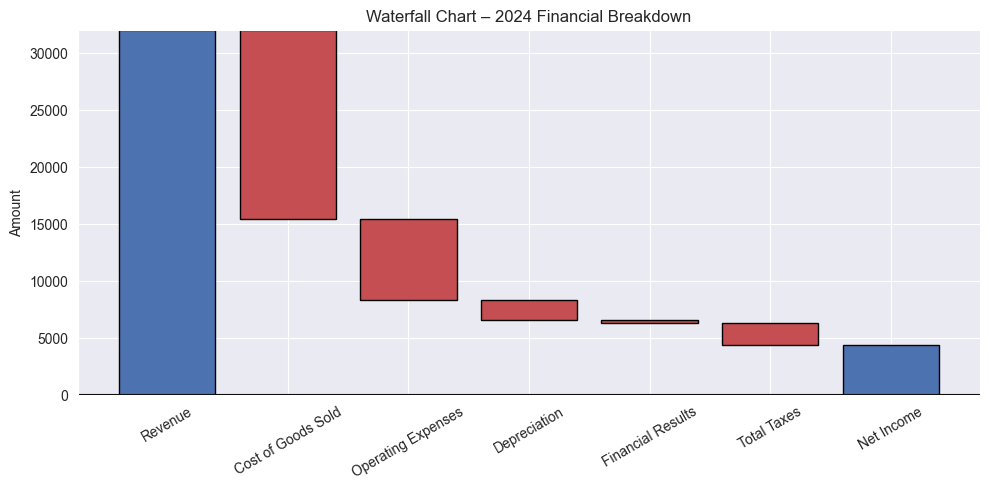

In [33]:
### Visualization 1: Waterfall Chart – 2024 Financial Breakdown
blue, red = palette[0], palette[3]

labels = [
    "Revenue", "Cost of Goods Sold", "Operating Expenses",
    "Depreciation", "Financial Results", "Total Taxes", "Net Income"
]

vals = [
    pl.loc["Revenue", "2024"],
    -pl.loc["CostOfGoodsSold", "2024"],
    -pl.loc["OperatingExpenses", "2024"],
    -pl.loc["DepreciationExpense", "2024"],
    pl.loc["FinancialResults", "2024"],
    -pl.loc["TotalTaxes", "2024"]
]

# Net Income is the amount required to close the chart at zero
net_income_final = -sum(vals)

vals.append(net_income_final)

# colors
colors = [blue if v >= 0 else red for v in vals]
# Force Net Income color to blue
colors[-1] = blue

# cumulative bottoms
cum = [0] + list(np.cumsum(vals[:-1]))

fig, ax = plt.subplots(figsize=(10,5))

for lbl, v, c, col in zip(labels, vals, cum, colors):
    ax.bar(lbl, v, bottom=c, color=col, edgecolor="black")

ax.axhline(0, color="black")
ax.set_title("Waterfall Chart – 2024 Financial Breakdown")
ax.set_ylabel("Amount")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


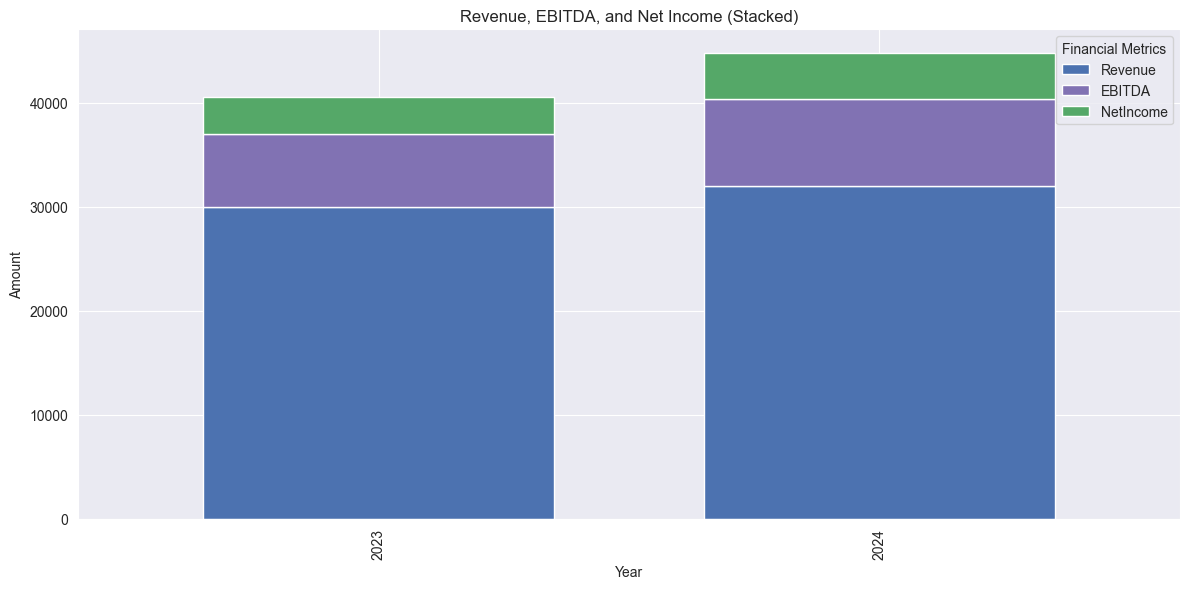

In [34]:
### Visualization 2: Stacked Bar Chart – Revenue, EBITDA, and Net Income

colors = [palette[0], palette[4], palette[2]]

pl_plot = pl.loc[["Revenue", "EBITDA", "NetIncome"]].T

ax = pl_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=colors,
    width=0.7,
    title="Revenue, EBITDA, and Net Income (Stacked)"
)

plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend(title="Financial Metrics", loc="best")
plt.tight_layout()
plt.show()


### 5- IFRS Financial Indicators

5.1 Liquidity Ratios

In [35]:
# Liquidity Ratios
liquidity = pd.DataFrame(index=bs.columns)

# Current Ratio = Current Assets / Current Liabilities
liquidity["Current_Ratio"] = (bs.loc["CurrentAssets"] / bs.loc["CurrentLiabilities"]).round(2)

# Quick Ratio = (Current Assets - Inventory) / Current Liabilities
liquidity["Quick_Ratio"] = ((bs.loc["CurrentAssets"] - bs.loc["Inventory"]) / bs.loc["CurrentLiabilities"]).round(2)

5.2 Leverage and Capital Structure

In [36]:
# Leverage and Capital Structure
leverage = pd.DataFrame(index=bs.columns)

# Net Debt = Total Debt (Revolving + Noncurrent Liabilities) - Cash
leverage["Net_Debt"] = (bs.loc["RevolvingCredit"] + bs.loc["NonCurrentLiabilities"] - bs.loc["Cash"]).round(2)

# Net Debt / EBITDA
leverage["Net_Debt_EBITDA"] = (leverage["Net_Debt"] / pl.loc["EBITDA"]).round(2)

# Debt to Equity = Total Debt / Total Equity
leverage["Debt_to_Equity"] = ((bs.loc["RevolvingCredit"] + bs.loc["NonCurrentLiabilities"]) / bs.loc["TotalEquity"]).round(2)

# Debt to Assets = Total Debt / Total Assets
leverage["Debt_to_Assets"] = ((bs.loc["RevolvingCredit"] + bs.loc["NonCurrentLiabilities"]) / bs.loc["TotalAssets"]).round(2)

# Interest Coverage = EBIT / |Financial Results|
leverage["Interest_Coverage"] = ((pl.loc["EBITDA"] - pl.loc["DepreciationExpense"]) / abs(pl.loc["FinancialResults"])).round(2)

5.3 Profitability Ratios

In [37]:
profit = pd.DataFrame(index=pl.columns)

# ROE = Net Income / Total Equity
profit["ROE (%)"] = ((pl.loc["NetIncome"] / bs.loc["TotalEquity"]) * 100).round(2)

# ROA = Net Income / Total Assets
profit["ROA (%)"] = ((pl.loc["NetIncome"] / bs.loc["TotalAssets"]) * 100).round(2)

# Gross Margin = Gross Profit / Revenue
profit["Gross Margin (%)"] = ((pl.loc["GrossProfit"] / pl.loc["Revenue"]) * 100).round(2)

# EBITDA Margin = EBITDA / Revenue
profit["EBITDA Margin (%)"] = ((pl.loc["EBITDA"] / pl.loc["Revenue"]) * 100).round(2)

# Net Margin = Net Income / Revenue
profit["Net Margin (%)"] = ((pl.loc["NetIncome"] / pl.loc["Revenue"]) * 100).round(2)

5.4 Efficiency Ratios

In [38]:
efficiency = pd.DataFrame(index=bs.columns)

# Asset Turnover = Revenue / Total Assets
efficiency["Asset Turnover"] = (pl.loc["Revenue"] / bs.loc["TotalAssets"]).round(2)

# Days Sales Outstanding (DSO) = (Accounts Receivable / Revenue) * 365
efficiency["Days Sales Outstanding (DSO)"] = ((bs.loc["AccountsReceivable"] / pl.loc["Revenue"]) * 365).round(0)

# Days Payable Outstanding (DPO) = (Accounts Payable / COGS) * 365
efficiency["Days Payable Outstanding (DPO)"] = ((bs.loc["AccountsPayable"] / pl.loc["CostOfGoodsSold"]) * 365).round(0)

# Days Inventory Outstanding (DIO) = (Inventory / COGS) * 365
efficiency["Days Inventory Outstanding (DIO)"] = ((bs.loc["Inventory"] / pl.loc["CostOfGoodsSold"]) * 365).round(0)


5.5 Cash Flow Indicators

In [39]:
cash = pd.DataFrame(index=cf.columns)

# Operating Cash Flow (CFO)
cash["CFO"] = cf.loc["CFO"].round(2)

# Free Cash Flow (FCF) = CFO + CFI (CFI normalmente é negativo)
cash["FCF"] = (cf.loc["CFO"] + cf.loc["CFI"]).round(2)

# CFO / Net Income Ratio
cash["CFO / Net Income"] = (cf.loc["CFO"] / pl.loc["NetIncome"]).round(2)

# FCF / Net Income Ratio
cash["FCF / Net Income"] = (cash["FCF"] / pl.loc["NetIncome"]).round(2)

# CFO / Total Assets (Cash Flow on Assets)
cash["CFO / Assets"] = (cf.loc["CFO"] / bs.loc["TotalAssets"]).round(2)

In [40]:
## 5.6 Consolidated IFRS Indicators Report
indicators = pd.concat([
    liquidity.T,
    leverage.T,
    profit.T,
    efficiency.T,
    cash.T
], axis=0)

# Export all indicators
#indicators.to_csv("py_files_cvs/ifrs_financial_indicators.csv")
#indicators.to_excel("py_files_cvs/ifrs_financial_indicators.xlsx")


# Display the summary
indicators

,2023,2024
Current_Ratio,2.29,2.26
Quick_Ratio,1.56,1.54
Net_Debt,7956.43,7608.24
Net_Debt_EBITDA,1.14,0.91
Debt_to_Equity,0.33,0.30
Debt_to_Assets,0.22,0.20
Interest_Coverage,15.77,19.69
ROE (%),13.25,15.19
ROA (%),8.74,10.24
Gross Margin (%),49.31,48.19
